In [43]:
import pandas as pd
from IPython.display import display

df = pd.read_csv('data.csv')
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

In [44]:
print('Rozmiar zbioru:', df.shape)
print("WNIOSKI: 418 wierszy to niewiele")

Rozmiar zbioru: (418, 20)
WNIOSKI: 418 wierszy to niewiele


In [45]:
print('\nTypy danych:')
display(df.dtypes.to_frame('dtype'))


Typy danych:


,dtype
ID,int64
N_Days,int64
Status,str
Drug,str
Age,int64
Sex,str
Ascites,str
Hepatomegaly,str
Spiders,str
Edema,str


In [46]:
missing_info = df.isna().sum().to_frame('missing_values')
missing_info['percentage'] = (df.isna().mean() * 100).round(2).astype(str) + '%'

print('\nBraki danych w kolumnach:')
display(missing_info)

print("WNIOSKI: 9 kolumn ma braki danych powyżej 25%")


Braki danych w kolumnach:


,missing_values,percentage
ID,0,0.0%
N_Days,0,0.0%
Status,0,0.0%
Drug,106,25.36%
Age,0,0.0%
Sex,0,0.0%
Ascites,106,25.36%
Hepatomegaly,106,25.36%
Spiders,106,25.36%
Edema,0,0.0%


WNIOSKI: 9 kolumn ma braki danych powyżej 25%


In [47]:
print('\nPodstawowe statystyki dla cech liczbowych:')
display(df[num_cols].describe().T)

print("WNIOSKI:")
print("najmłodszy pacjent miał 26 lat, natomiast wiekszość pacjentów (25%-75%) jest w wieku pomiędzy 42-58 lat")
print("czas obserwacji (n-days) jest bardzo rozpięty, sugeruje to duże zróżnicowanie postępowania choroby/bardzo różne fazy rozpoznania choroby i udania się do szpitala")


Podstawowe statystyki dla cech liczbowych:


,count,mean,std,min,25%,50%,75%,max
ID,418.0,209.500000,120.810458,1.00,105.2500,209.50,313.75,418.00
N_Days,418.0,1917.782297,1104.672992,41.00,1092.7500,1730.00,2613.50,4795.00
Age,418.0,18533.351675,3815.845055,9598.00,15644.5000,18628.00,21272.50,28650.00
Bilirubin,418.0,3.220813,4.407506,0.30,0.8000,1.40,3.40,28.00
Cholesterol,284.0,369.510563,231.944545,120.00,249.5000,309.50,400.00,1775.00
Albumin,418.0,3.497440,0.424972,1.96,3.2425,3.53,3.77,4.64
Copper,310.0,97.648387,85.613920,4.00,41.2500,73.00,123.00,588.00
Alk_Phos,312.0,1982.655769,2140.388824,289.00,871.5000,1259.00,1980.00,13862.40
SGOT,312.0,122.556346,56.699525,26.35,80.6000,114.70,151.90,457.25
Tryglicerides,282.0,124.702128,65.148639,33.00,84.2500,108.00,151.00,598.00


WNIOSKI:
najmłodszy pacjent miał 26 lat, natomiast wiekszość pacjentów (25%-75%) jest w wieku pomiędzy 42-58 lat
czas obserwacji (n-days) jest bardzo rozpięty, sugeruje to duże zróżnicowanie postępowania choroby/bardzo różne fazy rozpoznania choroby i udania się do szpitala


In [54]:
print(df['Stage'].value_counts().sort_index())
print("Widzimy że zdecydowana wiekszość pacjentów w zbiorze jest w ciężkim stanie (3 i 4 stadium choroby)")

Stage
1.0     21
2.0     92
3.0    155
4.0    144
Name: count, dtype: int64
Widzimy że zdecydowana wiekszość pacjentów w zbiorze jest w ciężkim stanie (3 i 4 stadium choroby)


In [49]:
for col in cat_cols:
    print(f"\nCecha: {col}")
    counts = df[col].value_counts(dropna=False)
    percents = df[col].value_counts(normalize=True, dropna=False) * 100
    summary = pd.concat([counts, percents.round(2)], axis=1, keys=['Liczba', 'Procent %'])
    display(summary)

print("WNIOSKI")
print("zdecydowana wiekszość wierszy to kobiety")
print("liczność ludzi przyjmujących placebo i d-pecicylamine jest prawie równe")
print("bardzo mało osób miało przeszczep, prawie 40% przypadków ze zbioru zakonczyło się śmiercią")



Cecha: Status


,Liczba,Procent %
Status,,
C,232,55.50
D,161,38.52
CL,25,5.98



Cecha: Drug


,Liczba,Procent %
Drug,,
D-penicillamine,158,37.80
Placebo,154,36.84
NaN,106,25.36



Cecha: Sex


...


Cecha: Spiders


,Liczba,Procent %
Spiders,,
N,222,53.11
NaN,106,25.36
Y,90,21.53



Cecha: Edema


,Liczba,Procent %
Edema,,
N,354,84.69
S,44,10.53
Y,20,4.78


WNIOSKI
zdecydowana wiekszość wierszy to kobiety
liczność ludzi przyjmujących placebo i d-pecicylamine jest prawie równe
bardzo mało osób miało przeszczep, prawie 40% przypadków ze zbioru zakonczyło się śmiercią


In [50]:
print('\nRozkład etykiety Stage:')
display(df['Stage'].value_counts(dropna=False).sort_index().to_frame('count'))
print("widzimy ze zdeydowana wiekszosc przypadkow w zbiorze to przypadki o dwoch najwyzszacych stadiach choroby, co moze tlumaczyc wysoka smiertelnosc, ktora byla wnioskiem w poprzedniej komorce")



Rozkład etykiety Stage:


,count
Stage,
1.0,21
2.0,92
3.0,155
4.0,144
NaN,6


widzimy ze zdeydowana wiekszosc przypadkow w zbiorze to przypadki o dwoch najwyzszacych stadiach choroby, co moze tlumaczyc wysoka smiertelnosc, ktora byla wnioskiem w poprzedniej komorce


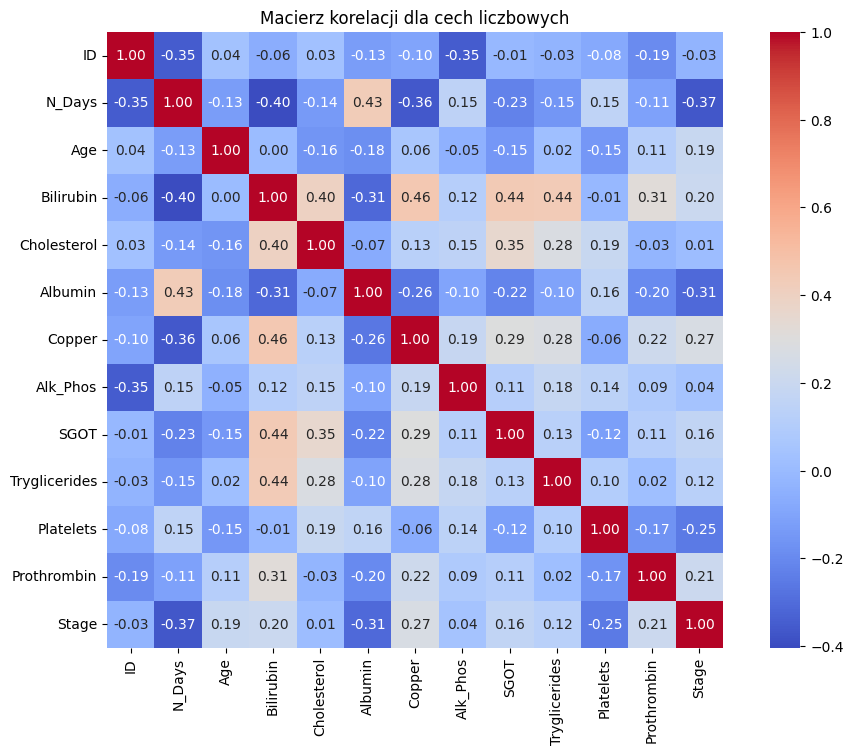

WNIOSKI:


In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Macierz korelacji dla cech liczbowych')
plt.show()

print("WNIOSKI:")


In [52]:
crosstab_drug = pd.crosstab(df['Drug'], df['Status'], normalize='index') * 100
display(crosstab_drug.round(2).astype(str) + '%')

drug_stats = df.groupby('Drug')[['Bilirubin', 'Prothrombin', 'Copper']].mean()
display(drug_stats.round(2))

print("WNIOSKI:")


Status,C,CL,D
Drug,,,
D-penicillamine,52.53%,6.33%,41.14%
Placebo,55.19%,5.84%,38.96%


,Bilirubin,Prothrombin,Copper
Drug,,,
D-penicillamine,2.87,10.65,97.64
Placebo,3.65,10.80,97.65


WNIOSKI:


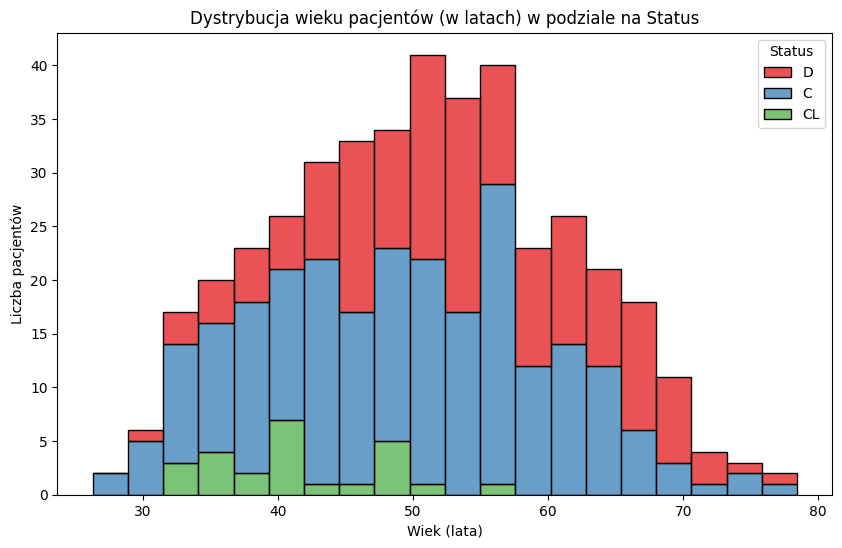

WNIOSKI:
- Rozkład zgonów (Status D) jest zauważalnie przesunięty w prawo, co oznacza, że starsi pacjenci (szczególnie powyżej 50 roku życia) stanowią największą grupę ryzyka.
- W grupie pacjentów nie seniorow (przed 60), znacznie częściej obserwujemy status C (pacjenci ocalejący/żyjący na koniec badań).


In [53]:
df['Age_years'] = df['Age'] / 365.25

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age_years', hue='Status', multiple='stack', bins=20, palette='Set1')
plt.title('Dystrybucja wieku pacjentów (w latach) w podziale na Status')
plt.xlabel('Wiek (lata)')
plt.ylabel('Liczba pacjentów')
plt.show()

print("WNIOSKI:")
print("- Rozkład zgonów (Status D) jest zauważalnie przesunięty w prawo, co oznacza, że starsi pacjenci (szczególnie powyżej 50 roku życia) stanowią największą grupę ryzyka.")
print("- W grupie pacjentów nie seniorow (przed 60), znacznie częściej obserwujemy status C (pacjenci ocalejący/żyjący na koniec badań).")